# Eddy deformation, ellipse orientation and tilt

**Primary question:** does surface elongation relate to measured tilt magnitude, and does tilt have a preferred direction relative to the ellipse? Parallel alignment is a possibility, not an assumed outcome. AE and CE are analysed separately.

**Secondary question:** do ellipse geometries at 50, 100, 200 and 300 m show stronger relationships? Every depth uses the **same existing whole-column `TiltDis` and `TiltDir`**; this notebook never recomputes tilt.

Run on Katana with the modular Parquet outputs. Start in this folder, the parent analysis folder, or the repository root. No new model-data cache is needed. Results are exploratory associations, not causal tests or out-of-sample predictions.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Locate this workflow without a machine-specific repository path.
candidates = [Path.cwd(), Path.cwd() / 'ellipse_tilt_analysis',
              Path.cwd() / 'seacofs_eddy_tilt_analysis' / 'ellipse_tilt_analysis',
              Path.cwd() / 'UNSW-PhD' / 'seacofs_eddy_tilt_analysis' / 'ellipse_tilt_analysis']
HERE = next((p.resolve() for p in candidates if (p / 'ellipse_tilt_tools.py').exists()), None)
if HERE is None:
    raise FileNotFoundError('Launch from ellipse_tilt_analysis, its parent, or the UNSW-PhD repository root.')
sys.path.insert(0, str(HERE.parent))
sys.path.insert(0, str(HERE))
import seacofs_tilt_tools as tilt
import ellipse_tilt_tools as et

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'savefig.dpi': 300})
DEPTHS = (0, 50, 100, 200, 300)
RUN_DEPTHS = True
# Matches compute_weighted_tilt's bearing_offset_deg in config/local.yaml.
BEARING_OFFSET_DEG = 20.0
MIN_DIRECTION_AR = 1.1
MIN_DIRECTION_TILT_KM = 5.0
MAX_AR = 5.0
MAX_DEPTH_BRACKET_M = 100.0
NEAREST_TOLERANCE_M = 25.0
MIN_DAYS_PER_EDDY = 5
MIN_EDDIES = 10
N_BOOT = 1000
SEED = 42
SAVE_OUTPUTS = False
OUTPUT = HERE / 'outputs'

paths = tilt.Paths()  # Override individual paths here if your files moved.
stat_kwargs = dict(n_boot=N_BOOT, seed=SEED, min_days=MIN_DAYS_PER_EDDY, min_eddies=MIN_EDDIES)
figures = {}
def show_figure(name, fig):
    figures[name] = fig
    plt.show()

## 1. Geometry and conventions

The fitted matrix defines $\rho^2 = \mathbf{x}^T Q\mathbf{x}$. The **smallest eigenvalue** identifies the longest axis; major/minor axis ratio is $\sqrt{\lambda_{max}/\lambda_{min}}$. Invalid/non-positive-definite matrices are rejected. Exactly circular ellipses have no defined major-axis direction.

The ML helper `_major_axis_encoding` uses doubled mathematical angles. Here we instead form a bearing directly from the major eigenvector `(vx, vy)` as `atan2(vx, vy) + BEARING_OFFSET_DEG`, matching `core/tilt.py`'s tilt bearing. Eigenvector sign is irrelevant because the axis is modulo 180°. Do not apply an additional grid rotation.

The signed tilt–axis offset lies in [-90°, 90°); its absolute value lies in [0°, 90°]. `cos(2 offset)` is +1 for parallel and −1 for perpendicular. Its mean alone can miss intermediate or multimodal preferences, so retain the full histogram and `sin(2 offset)` too. Neither statistic distinguishes the two ends of a major axis.

Thresholds are exploratory defaults: AR ≥1.1 and tilt ≥5 km for directional analyses, AR ≤5 for all analyses (matching the surface QC ceiling). Magnitude analyses retain circular shapes and zero tilt. Sensitivity tests vary the directional thresholds below.

In [2]:
grid = tilt.load_grid(paths.grid, paths.z_r)
surface, _ = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
if surface.duplicated(['Eddy', 'Day']).any():
    raise ValueError('Duplicate surface/tilt join keys; resolve before analysis.')
# Core means match the case-study PV context; regimes are descriptive covariates.
USE_PV_CACHE = True
surface = tilt.add_pv_gradient_terms(
    surface,
    grid,
    core_mean=True,
    frac=1.0,
    surface_method="esp_gaussian",
    averaging="nonlinear",
    use_max_abs_w=True,
    max_depth_m=1000,
    use_cache=USE_PV_CACHE,
)
# surface = tilt.add_pv_gradient_terms(surface, grid, core_mean=True)
print(f'Surface input: {len(surface):,} eddy-days; {surface.Eddy.nunique():,} eddies')

# Independent geometric check: synthetic x, y and 45-degree major axes.
check = pd.DataFrame({'q11': [.25, 1, .625, 1], 'q12': [0, 0, -.375, 0],
                      'q22': [1, .25, .625, 1]})
check = et.ellipse_geometry(check, BEARING_OFFSET_DEG)
expected = (np.array([90, 0, 45]) + BEARING_OFFSET_DEG) % 180
assert np.allclose(et.axial_difference(check.MajorBearing.iloc[:3], expected), 0)
assert np.allclose(check.AxisRatio.iloc[:3], 2)
assert np.isnan(check.MajorBearing.iloc[3])
display(check)

Surface input: 127,426 eddy-days; 2,982 eddies


,q11,q12,q22,AxisRatio,MajorBearing,Q_valid
0,0.250,0.000,1.000,2.0,110.0,True
1,1.000,0.000,0.250,2.0,20.0,True
2,0.625,-0.375,0.625,2.0,65.0,True
3,1.000,0.000,1.000,1.0,NaN,True


## 2. Surface and depth sampling; coverage audit

Load only the necessary vertical-profile columns. Use exact levels where available; otherwise linearly interpolate **Q entries**, not axis angles or axis ratios. Adjacent bracketing matrices must both be positive definite and no more than 100 m apart. No extrapolation, bridging invalid levels or silent averaging of duplicate profile rows is allowed. Depth is positive down.

Interpolating Q can reduce apparent elongation when axes rotate between levels; nearest-level sensitivity is included later. Surface Q is processed/smoothed by the upstream pipeline, whereas subsurface fits may have different smoothing and uncertainty. Any apparent depth optimum must be interpreted with that difference in mind.

In [3]:
profile_columns = ['Eddy', 'Day', 'Depth', 'q11', 'q12', 'q22']
if RUN_DEPTHS:
    if Path(paths.vert).suffix.lower() == '.parquet':
        profiles = pd.read_parquet(paths.vert, columns=profile_columns)
    else:
        profiles = tilt.load_vert(paths, dic_form=False)
        if not isinstance(profiles, pd.DataFrame):
            raise TypeError('Use the modular long-form profiles.parquet, not a legacy dictionary.')
        profiles = profiles[profile_columns]
    profiles = profiles.merge(surface[['Eddy', 'Day']], on=['Eddy', 'Day'],
                              how='inner', validate='many_to_one')
    sampled = et.sample_depth_geometry(profiles, DEPTHS[1:], max_gap_m=MAX_DEPTH_BRACKET_M)
else:
    sampled = pd.DataFrame(columns=['Eddy', 'Day', 'ShapeDepth', 'q11', 'q12', 'q22',
                                    'DepthLower', 'DepthUpper', 'DepthMethod'])
all_shapes = et.build_analysis_table(surface, sampled, BEARING_OFFSET_DEG)
magnitude = et.select_rows(all_shapes, max_ar=MAX_AR)
direction = et.select_rows(all_shapes, directional=True, min_ar=MIN_DIRECTION_AR,
                           min_tilt=MIN_DIRECTION_TILT_KM, max_ar=MAX_AR)
coverage = []
for label, frame in [('Available geometry', all_shapes), ('Magnitude QC', magnitude),
                     ('Directional QC', direction)]:
    counts = frame.groupby(['ShapeDepth', 'Cyc']).agg(observations=('Day', 'size'), eddies=('Eddy', 'nunique'))
    coverage.append(counts.assign(sample=label).reset_index())
coverage = pd.concat(coverage, ignore_index=True)
display(coverage)
display(pd.crosstab(all_shapes.ShapeDepth, all_shapes.DepthMethod))
if 'AR' in surface:
    audit = all_shapes.loc[all_shapes.ShapeDepth.eq(0), ['AR', 'AxisRatio']].dropna()
    print('Max absolute difference: stored AR versus Q-derived AR:',
          (audit.AR-audit.AxisRatio).abs().max())
print('Invalid Q matrices:', int((~all_shapes.Q_valid).sum()))

,ShapeDepth,Cyc,observations,eddies,sample
0,0.0,AE,64952,1446,Available geometry
1,0.0,CE,62474,1536,Available geometry
2,50.0,AE,59910,1446,Available geometry
3,50.0,CE,57350,1536,Available geometry
4,100.0,AE,58657,1446,Available geometry
5,100.0,CE,56789,1536,Available geometry
6,200.0,AE,55303,1433,Available geometry
7,200.0,CE,55268,1535,Available geometry
8,300.0,AE,52303,1415,Available geometry
9,300.0,CE,53552,1527,Available geometry


DepthMethod,interpolate,surface
ShapeDepth,,
0.0,0,127426
50.0,117260,0
100.0,115446,0
200.0,110571,0
300.0,105855,0


Max absolute difference: stored AR versus Q-derived AR: 5.329070518200751e-15
Invalid Q matrices: 0


## 3. Surface elongation versus tilt distance

Each scatter point is one eddy's median AR and median tilt over the same available days. Binned lines and interquartile shading are descriptive. Formal summaries require at least five valid days per eddy and ten eddies per group.

Between-eddy Spearman correlation asks whether eddies with larger typical AR also have larger typical tilt. The within-eddy slope de-means AR and tilt within each eddy and gives each eddy equal total weight; units are km of tilt per unit AR. Its bootstrap resamples whole eddies, retaining serial dependence. These are different estimands and need not agree.

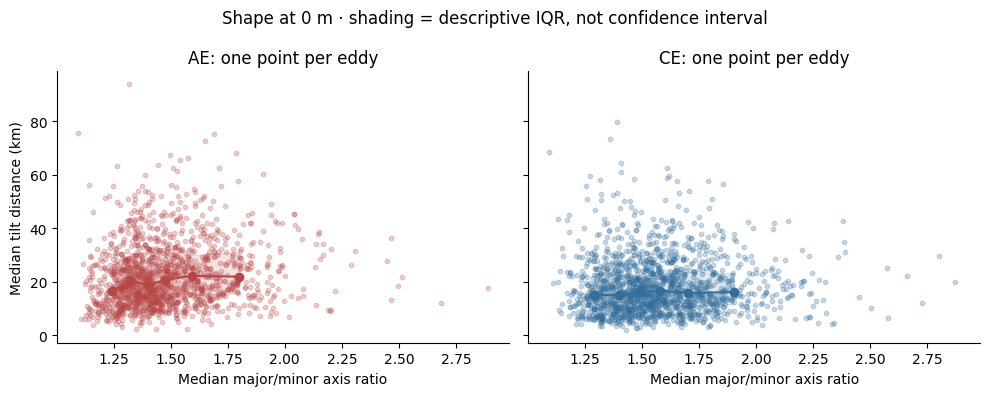

,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,Between-eddy Spearman,0.172120,0.121444,0.223589,1377,51059
1,0.0,AE,Within-eddy slope (km / AR),4.636080,3.433038,5.841963,1377,51059
2,0.0,CE,Between-eddy Spearman,0.047034,-0.004477,0.099168,1519,50459
3,0.0,CE,Within-eddy slope (km / AR),2.828185,2.015761,3.663134,1519,50459


In [4]:
show_figure('01_surface_magnitude', et.plot_magnitude(magnitude))
mag_stats = et.magnitude_summary(magnitude, **stat_kwargs)
display(mag_stats.loc[mag_stats.ShapeDepth.eq(0)])

## 4. Surface ellipse–tilt directional alignment

Every eddy has equal total weight in each histogram. The dashed line is the uniform-angle reference (5.56% per 5° bin), **not an independence test**: common geographic orientations can produce apparent alignment without direct coupling.

Confidence intervals below use one mean per eddy. Positive mean cosine favours parallel over perpendicular alignment; negative favours perpendicular. Inspect the distribution for oblique peaks or mixtures, even if mean cosine and sine are near zero. Mean absolute angle of 45° alone does not establish uniformity.

In [5]:
direction.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       ...
       'DepthLower', 'DepthUpper', 'DepthMethod', 'AxisRatio', 'MajorBearing',
       'Q_valid', 'SignedAlignment', 'AlignmentDeg', 'AlignmentCos2',
       'AlignmentSin2'],
      dtype='object', length=103)

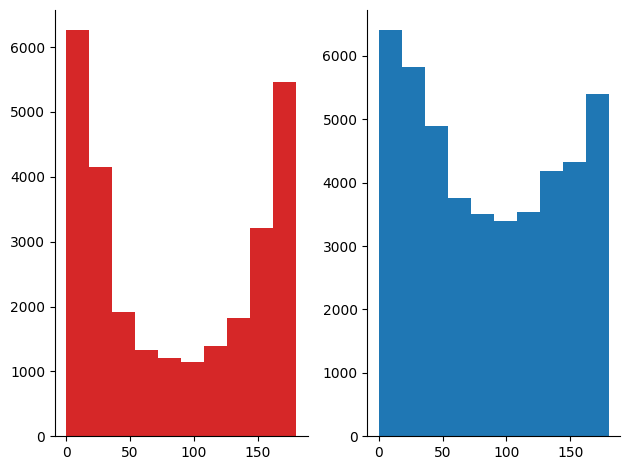

In [6]:
fig, axs = plt.subplots(1, 2)
for (cyc, ax) in zip(['AE', 'CE'], axs):
    df = direction[(direction.Cyc==cyc)&(direction.Region.isin(['S1', 'S2']))]
    ax.hist(df.MajorBearing, color='tab:red' if cyc=='AE' else 'tab:blue')
plt.tight_layout()

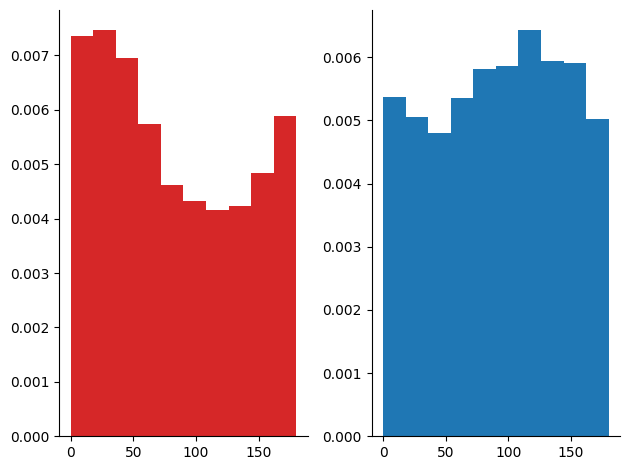

In [7]:
fig, axs = plt.subplots(1, 2)
for (cyc, ax) in zip(['AE', 'CE'], axs):
    df = direction[(direction.Cyc==cyc)&(direction.topo_plan_ratio<0)]
    ax.hist(df.MajorBearing, color='tab:red' if cyc=='AE' else 'tab:blue', density=True)
plt.tight_layout()

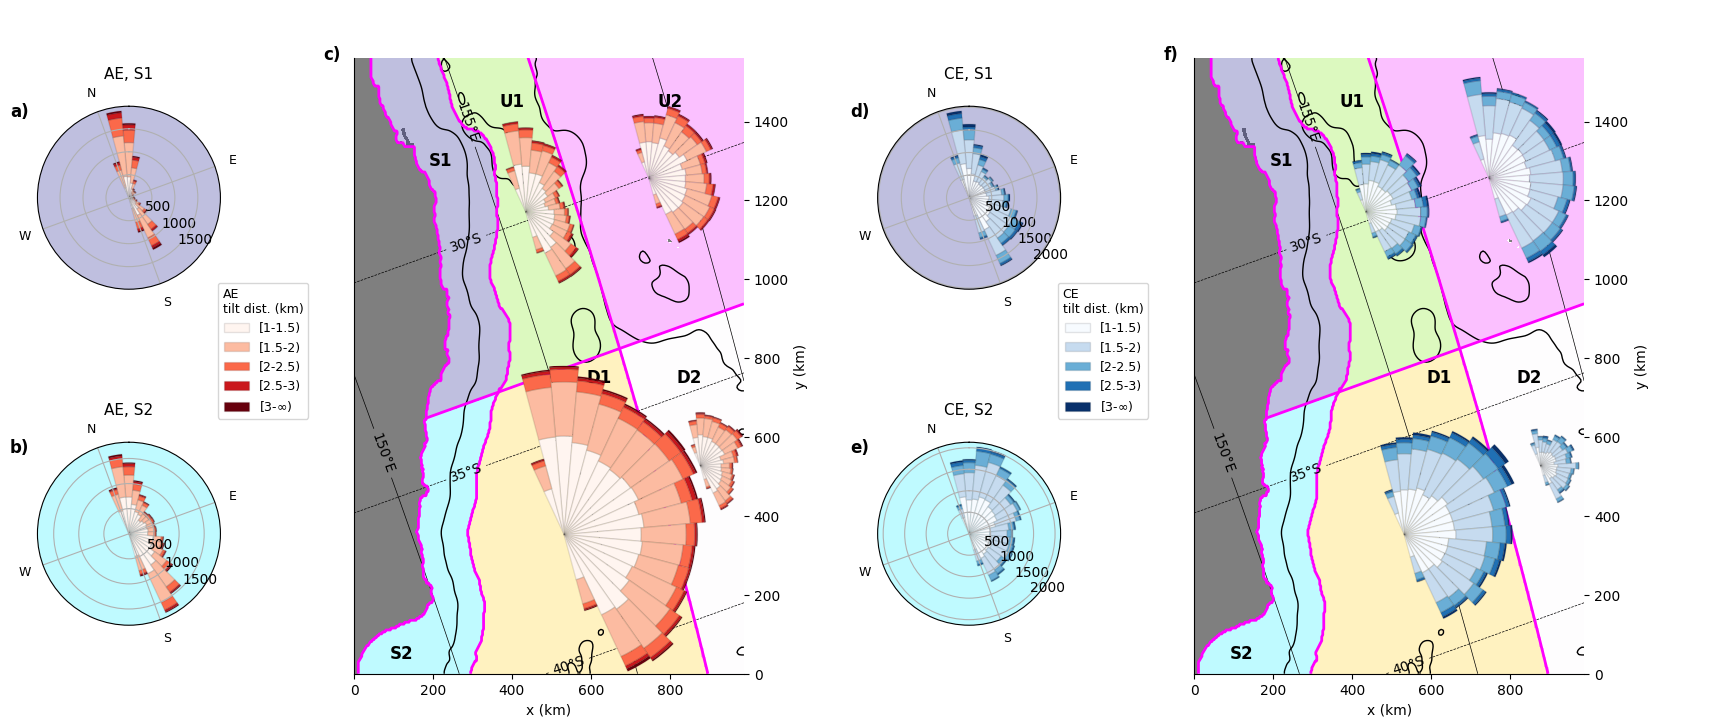

In [8]:
fig, axs = tilt.rose_plot(direction, grid, mag="AxisRatio", theta="MajorBearing", mag_bins=[1,1.5,2,2.5,3,np.inf])

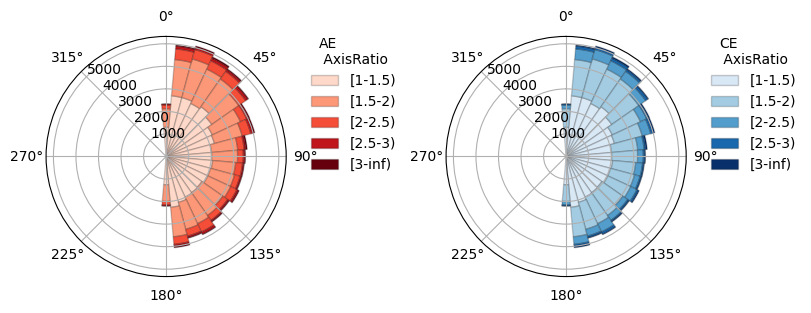

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(8, 5), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins=[1,1.5,2,2.5,3,np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = direction[direction.topo_plan_ratio<0]
    tilt.plot_windrose(ax, subset, title='', mag='AxisRatio', theta='MajorBearing', mag_bins=mag_bins, colors=colors)
    ax.legend(title=f"{cyc}\n AxisRatio", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
plt.show()

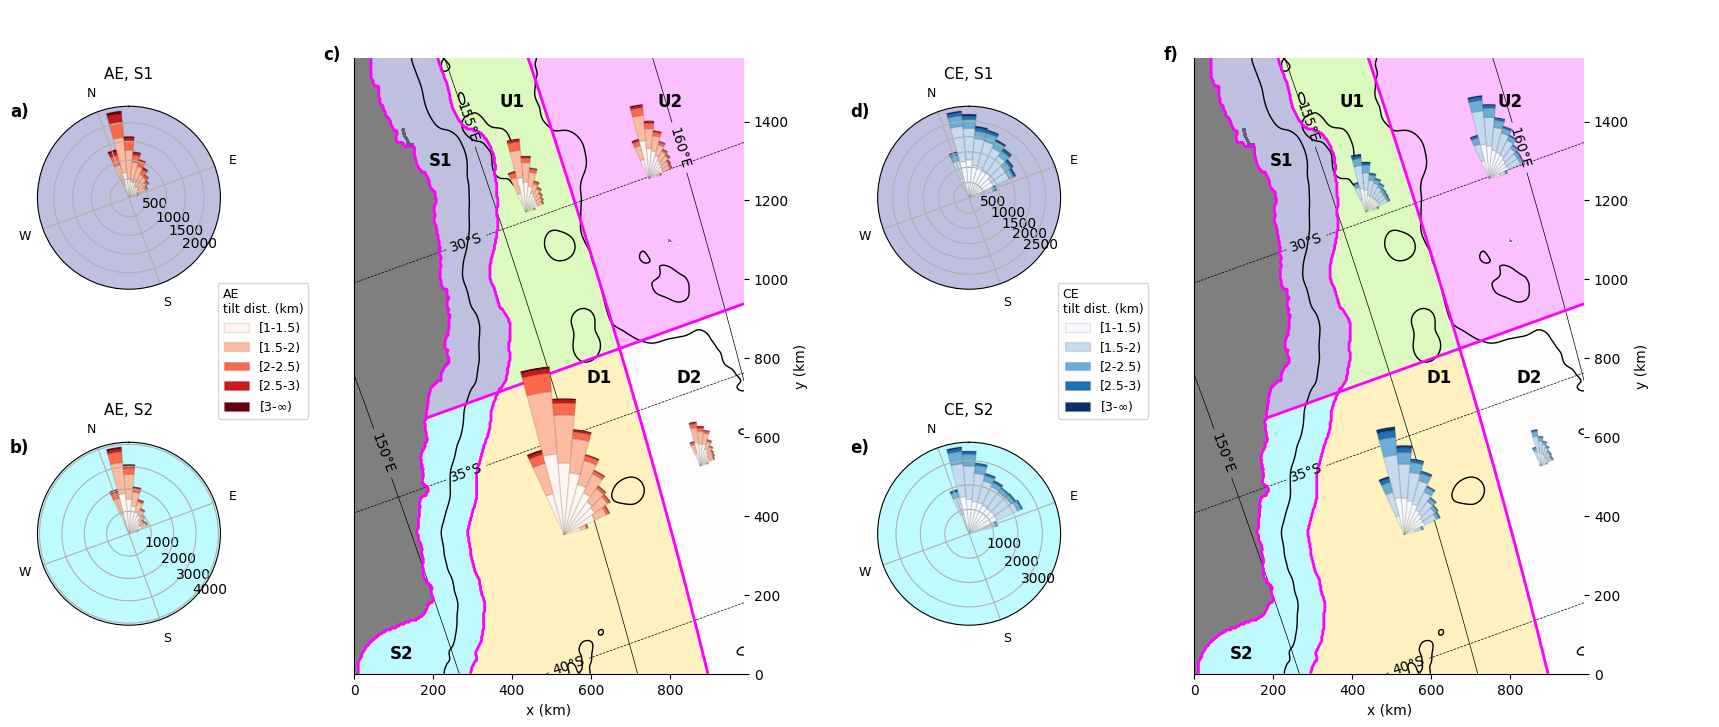

In [10]:
fig, axs = tilt.rose_plot(direction, grid, mag="AxisRatio", theta="AlignmentDeg", mag_bins=[1,1.5,2,2.5,3,np.inf])

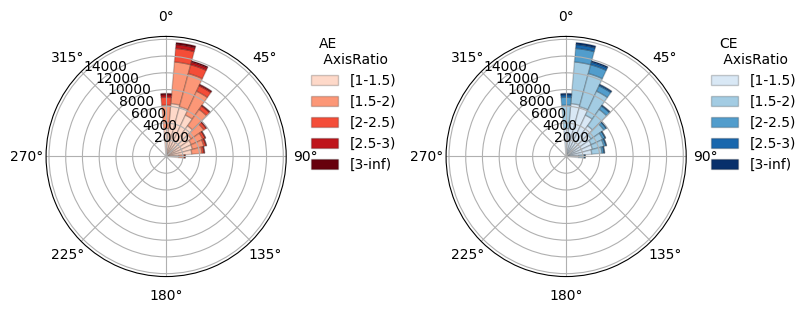

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(8, 5), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins=[1,1.5,2,2.5,3,np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = direction[direction.topo_plan_ratio<0]
    tilt.plot_windrose(ax, subset, title='', mag='AxisRatio', theta='AlignmentDeg', mag_bins=mag_bins, colors=colors)
    ax.legend(title=f"{cyc}\n AxisRatio", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
plt.show()

ALL


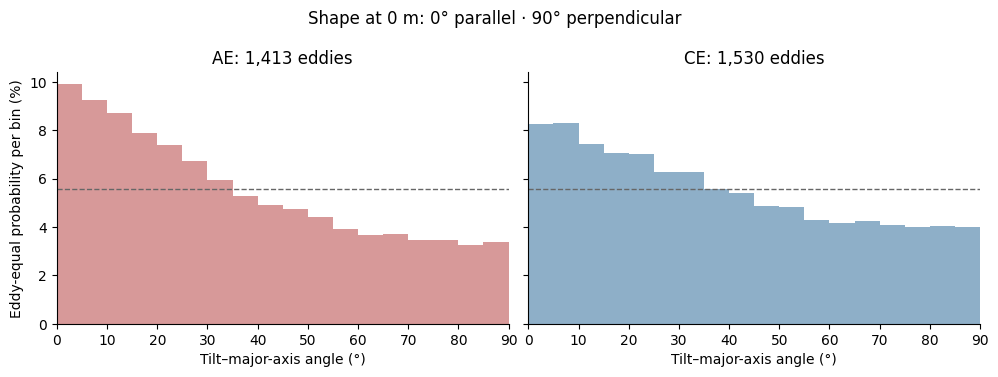

,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,AlignmentCos2,0.261271,0.243957,0.278237,1366,43812
1,0.0,AE,AlignmentSin2,-0.049525,-0.066470,-0.032356,1366,43812
2,0.0,AE,AlignmentDeg,35.362302,34.741639,36.012857,1366,43812
3,0.0,CE,AlignmentCos2,0.181403,0.163312,0.198459,1511,43368
4,0.0,CE,AlignmentSin2,0.039404,0.022102,0.056605,1511,43368
5,0.0,CE,AlignmentDeg,38.340860,37.697170,39.006368,1511,43368


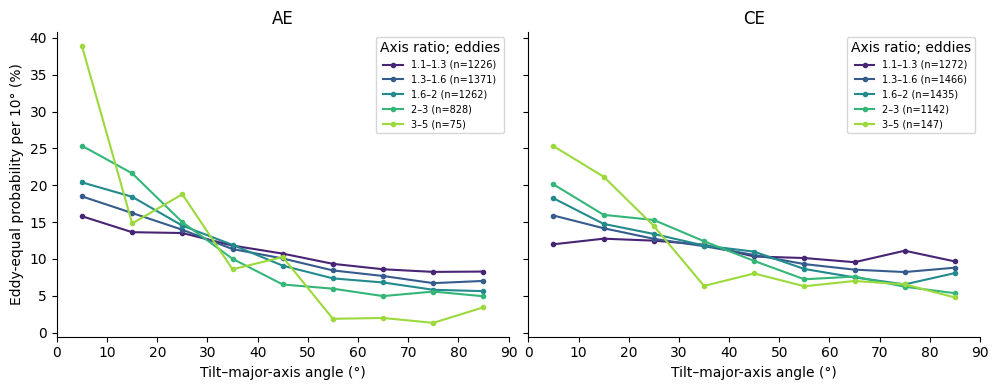

Shelf


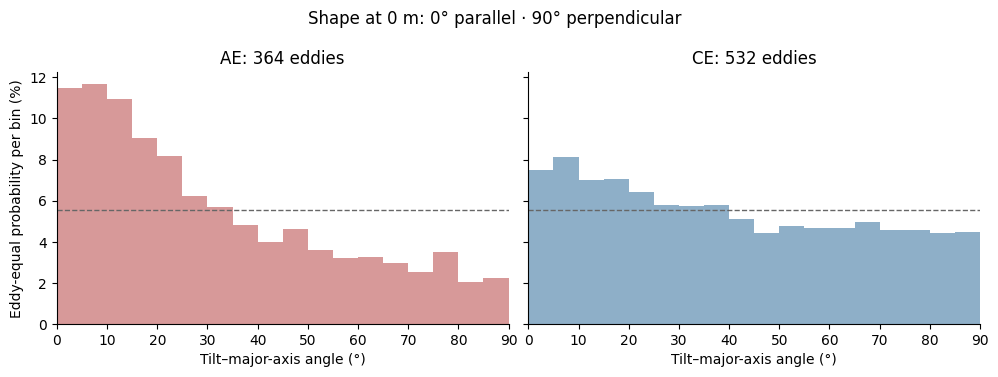

,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,AlignmentCos2,0.341630,0.297137,0.384112,285,5447
1,0.0,AE,AlignmentSin2,-0.148161,-0.187678,-0.106163,285,5447
2,0.0,AE,AlignmentDeg,32.354362,30.750429,34.036508,285,5447
3,0.0,CE,AlignmentCos2,0.129824,0.092601,0.162845,473,8935
4,0.0,CE,AlignmentSin2,0.028244,-0.005798,0.063904,473,8935
5,0.0,CE,AlignmentDeg,40.259844,39.040913,41.637973,473,8935


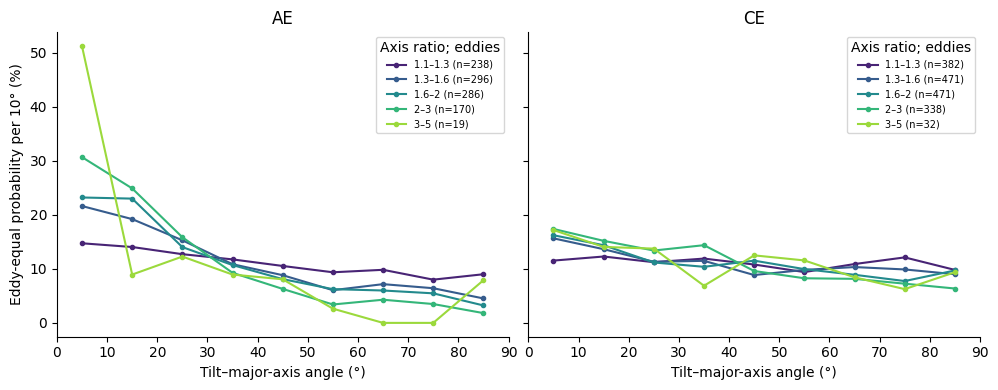

off-shelf


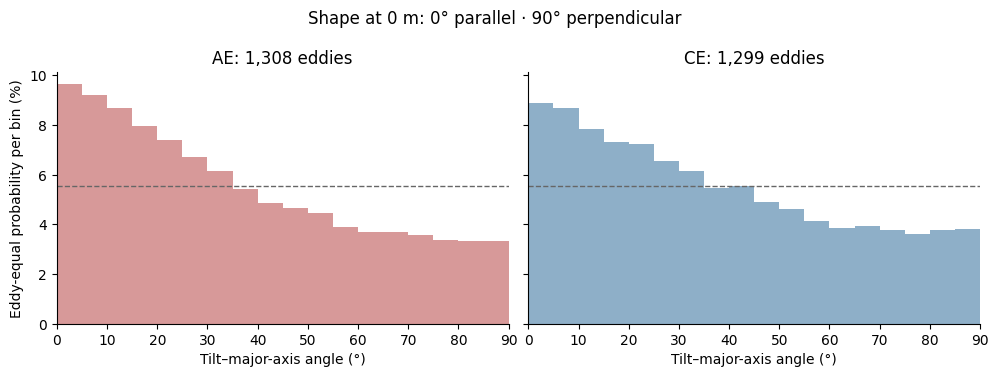

,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,AlignmentCos2,0.258020,0.240422,0.276176,1251,38152
1,0.0,AE,AlignmentSin2,-0.041608,-0.058934,-0.023285,1251,38152
2,0.0,AE,AlignmentDeg,35.487199,34.799962,36.147010,1251,38152
3,0.0,CE,AlignmentCos2,0.213216,0.192342,0.235223,1232,34185
4,0.0,CE,AlignmentSin2,0.047990,0.027563,0.066266,1232,34185
5,0.0,CE,AlignmentDeg,37.150859,36.334984,37.919873,1232,34185


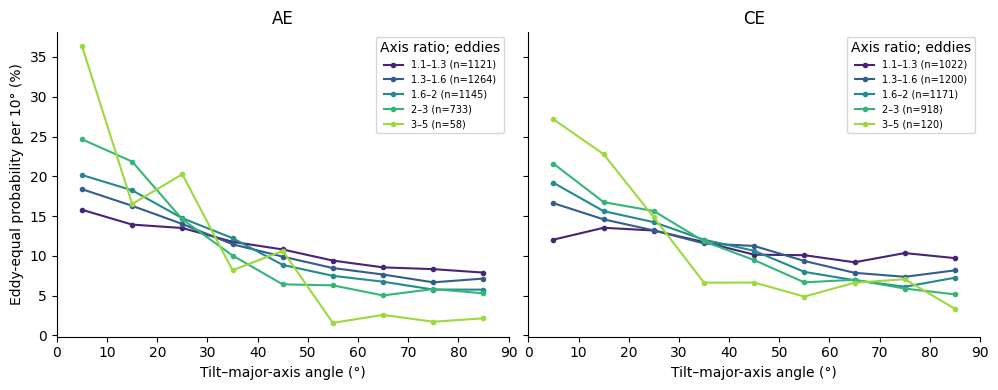

In [12]:
df = direction.copy()
for k, df in enumerate([direction.copy(),
           direction[direction.Region.isin(['S1', 'S2'])].copy(),
           direction[direction.Region.isin(['U1','U2','D1','D2'])].copy()]):
    if k==0:
        print('ALL')
    elif k ==1:
        print('Shelf')
    else:
        print('off-shelf')
    show_figure('02_surface_alignment', et.plot_alignment(df))
    dir_stats = et.alignment_summary(df, **stat_kwargs)
    display(dir_stats.loc[dir_stats.ShapeDepth.eq(0)])
    show_figure('03_surface_alignment_by_elongation', et.plot_interaction(df))

“Probability per 10° bin (%; equal weight per eddy)”\
It means the percentage of observations in each 10° angle bin, weighted so every eddy contributes equally.
For example:
- An eddy with 100 observations gives each observation a weight of 1/100.
- An eddy with 10 observations gives each observation a weight of 1/10.
Both eddies therefore contribute the same total weight. Long-lived eddies don’t dominate the plot simply because they have more measurements.
A value of 20% in the 0–10° bin means that, after this weighting, 20% of the distribution falls within 10° of parallel alignment. It does not mean 20% of eddies always tilt within that angle.
In the axis-ratio comparison, weighting is calculated separately within each axis-ratio class. Each curve’s bins sum to 100%.
A clearer axis label would be:


## 5. Regional and PV-regime context

Upstream includes S1/U1/U2; downstream includes S2/D1/D2. PV categories use the natural-log topographic/planetary ratio: planetary <−log(2), topographic >log(2), otherwise mixed. These categories describe sampled conditions, not proven dynamical control.

Repeat both relationships within each group. An eddy can contribute to multiple sectors/regimes on different days, so these rows are not independent comparisons. Group-specific intervals are pointwise, with no multiple-testing correction. Sparse groups return missing estimates rather than unstable intervals.

In [13]:
context_tables = {}
for context in ['Sector', 'PVRegime']:
    groups = ('ShapeDepth', 'Cyc', context)
    m = et.magnitude_summary(magnitude.loc[magnitude.ShapeDepth.eq(0)], groups=groups, **stat_kwargs)
    d = et.alignment_summary(direction.loc[direction.ShapeDepth.eq(0)], groups=groups, **stat_kwargs)
    context_tables[context + '_magnitude'] = m
    context_tables[context + '_direction'] = d
    print(context)
    display(m)
    display(d.loc[d.metric.eq('AlignmentCos2')])

Sector


,ShapeDepth,Cyc,Sector,metric,estimate,low,high,eddies,observations
0,0.0,AE,Downstream,Between-eddy Spearman,0.226578,0.167213,0.288568,892,33843
1,0.0,AE,Downstream,Within-eddy slope (km / AR),5.370543,4.021568,6.680114,892,33843
2,0.0,AE,Upstream,Between-eddy Spearman,0.041650,-0.039320,0.128164,577,17155
3,0.0,AE,Upstream,Within-eddy slope (km / AR),4.080680,1.770375,6.270558,577,17155
4,0.0,CE,Downstream,Between-eddy Spearman,0.087019,0.025993,0.153834,900,28127
5,0.0,CE,Downstream,Within-eddy slope (km / AR),3.061796,2.077971,4.020778,900,28127
6,0.0,CE,Upstream,Between-eddy Spearman,-0.021464,-0.093448,0.052739,676,22231
7,0.0,CE,Upstream,Within-eddy slope (km / AR),2.317441,0.999745,3.536004,676,22231


,ShapeDepth,Cyc,Sector,metric,estimate,low,high,eddies,observations
0,0.0,AE,Downstream,AlignmentCos2,0.260758,0.237298,0.281131,883,28190
3,0.0,AE,Upstream,AlignmentCos2,0.272400,0.244434,0.301191,571,15554
6,0.0,CE,Downstream,AlignmentCos2,0.187407,0.161779,0.211492,891,22811
9,0.0,CE,Upstream,AlignmentCos2,0.176887,0.151474,0.202813,670,20449


PVRegime


,ShapeDepth,Cyc,PVRegime,metric,estimate,low,high,eddies,observations
0,0.0,AE,Mixed,Between-eddy Spearman,0.153475,0.073902,0.227321,689,16091
1,0.0,AE,Mixed,Within-eddy slope (km / AR),5.216075,3.372644,7.275438,689,16091
2,0.0,AE,Planetary,Between-eddy Spearman,0.266556,0.155031,0.380541,256,4386
3,0.0,AE,Planetary,Within-eddy slope (km / AR),6.210481,2.458023,9.714509,256,4386
4,0.0,AE,Topographic,Between-eddy Spearman,0.140759,0.082683,0.200141,1131,29263
5,0.0,AE,Topographic,Within-eddy slope (km / AR),4.943749,3.426255,6.547931,1131,29263
6,0.0,CE,Mixed,Between-eddy Spearman,0.024269,-0.059641,0.098223,609,10080
7,0.0,CE,Mixed,Within-eddy slope (km / AR),4.030236,2.741153,5.372500,609,10080
8,0.0,CE,Planetary,Between-eddy Spearman,0.027021,-0.165106,0.204386,146,1472
9,0.0,CE,Planetary,Within-eddy slope (km / AR),1.986822,-1.985740,6.110244,146,1472


,ShapeDepth,Cyc,PVRegime,metric,estimate,low,high,eddies,observations
0,0.0,AE,Mixed,AlignmentCos2,0.277583,0.249987,0.304707,664,13061
3,0.0,AE,Planetary,AlignmentCos2,0.320097,0.274841,0.366939,241,3655
6,0.0,AE,Topographic,AlignmentCos2,0.266002,0.242654,0.287692,1110,25741
9,0.0,CE,Mixed,AlignmentCos2,0.233480,0.196378,0.269056,565,8284
12,0.0,CE,Planetary,AlignmentCos2,0.236824,0.150817,0.316198,131,1167
15,0.0,CE,Topographic,AlignmentCos2,0.175212,0.154123,0.195888,1357,32549


## 6. Within-eddy rotation and deformation changes

The earlier within-eddy magnitude slope tests whether departures from an eddy's typical shape accompany departures from its typical tilt. Here use consecutive qualified observations at most one day apart; excluded days are not bridged.

Tilt turns are treated axially for comparison with ellipse rotation. This intentionally ignores 180° reversals of the tilt arrow. Positive `TurnAgreement = cos[2(tilt turn − axis turn)]` means similar turns, but two nearly stationary directions also agree. Therefore summarise only pairs with at least 5° of **ellipse-axis rotation**; vary that threshold if this becomes a main result. Fast rotations ≥90° between observations are aliased and cannot be resolved.

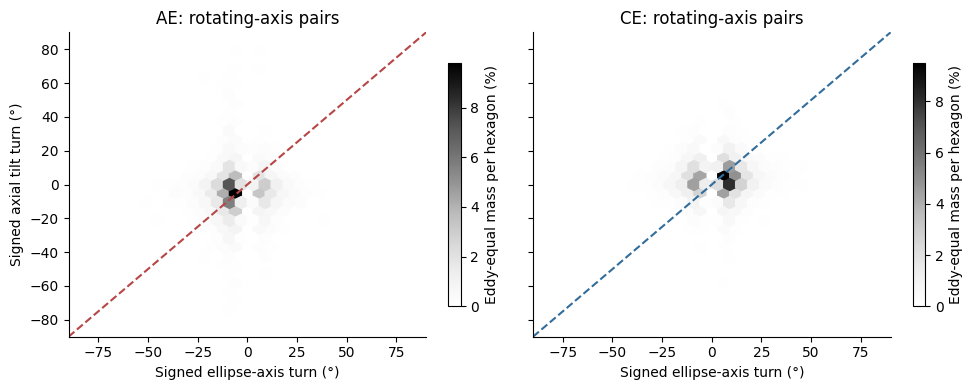

,Cyc,eddies,estimate,low,high
0,AE,1062,0.776116,0.766840,0.785952
1,CE,1198,0.813579,0.805994,0.820927


In [14]:
pairs = et.rotation_pairs(direction.loc[direction.ShapeDepth.eq(0)], max_gap_days=1)
rotation_results = []
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, (cyc, colour) in zip(axes, et.COLOURS.items()):
    g = pairs.loc[pairs.Cyc.eq(cyc) & pairs.AxisTurn.abs().ge(5)].copy()
    per_eddy = g.groupby('Eddy').agg(agreement=('TurnAgreement', 'mean'), n=('Day', 'size'))
    per_eddy = per_eddy.loc[per_eddy.n >= MIN_DAYS_PER_EDDY]
    estimate, low, high = et.bootstrap_stat(per_eddy[['agreement']].to_numpy(), np.mean,
                                           N_BOOT, SEED, MIN_EDDIES)
    rotation_results.append(dict(Cyc=cyc, eddies=len(per_eddy), estimate=estimate, low=low, high=high))
    if len(g):
        weights = et.equal_eddy_weights(g)
        hb = ax.hexbin(g.AxisTurn, g.TiltTurn, C=100 * weights / weights.sum(),
                       reduce_C_function=np.sum, extent=(-90, 90, -90, 90),
                       gridsize=30, mincnt=1, cmap='Greys', vmin=0)
        fig.colorbar(hb, ax=ax, label='Eddy-equal mass per hexagon (%)', shrink=.8)
    ax.plot([-90, 90], [-90, 90], '--', color=colour)
    ax.set(title=f'{cyc}: rotating-axis pairs', xlabel='Signed ellipse-axis turn (°)',
           xlim=(-90,90), ylim=(-90,90))
axes[0].set_ylabel('Signed axial tilt turn (°)')
fig.tight_layout()
show_figure('04_surface_rotation', fig)
rotation_results = pd.DataFrame(rotation_results)
display(rotation_results)

## 7. Depth comparison: available and matched eddy-days

First show all available observations at each depth. Then require the **same eddy-days at all five depths**, separately for magnitude QC and directional QC. This distinguishes depth dependence from selection of deeper-reaching eddies. The matched sample is selective and is not representative of all eddies; report its coverage.

Pointwise CI overlap/non-overlap is not a paired test of differences between depths. Do not select a “best depth” on these exploratory estimates alone.

Matched magnitude eddy-days: 97710
Matched direction eddy-days: 78723
Available


,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,Between-eddy Spearman,0.172120,0.121444,0.223589,1377,51059
1,0.0,AE,Within-eddy slope (km / AR),4.636080,3.433038,5.841963,1377,51059
2,0.0,CE,Between-eddy Spearman,0.047034,-0.004477,0.099168,1519,50459
3,0.0,CE,Within-eddy slope (km / AR),2.828185,2.015761,3.663134,1519,50459
4,50.0,AE,Between-eddy Spearman,0.166893,0.116284,0.217395,1377,51039
5,50.0,AE,Within-eddy slope (km / AR),3.729925,2.730943,4.773462,1377,51039
6,50.0,CE,Between-eddy Spearman,0.029161,-0.020114,0.082305,1519,50415
7,50.0,CE,Within-eddy slope (km / AR),2.620087,1.903860,3.380130,1519,50415
8,100.0,AE,Between-eddy Spearman,0.166797,0.116751,0.219763,1377,51040
9,100.0,AE,Within-eddy slope (km / AR),4.214656,3.040702,5.312412,1377,51040


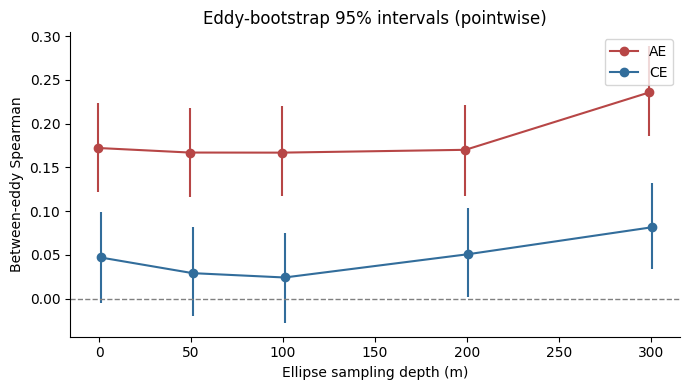

Matched


,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,Between-eddy Spearman,0.185515,0.131661,0.235757,1333,48518
1,0.0,AE,Within-eddy slope (km / AR),4.935969,3.505201,6.249245,1333,48518
2,0.0,CE,Between-eddy Spearman,0.035074,-0.015539,0.088213,1491,48989
3,0.0,CE,Within-eddy slope (km / AR),2.896862,2.123165,3.674698,1491,48989
4,50.0,AE,Between-eddy Spearman,0.178619,0.128750,0.229016,1333,48518
5,50.0,AE,Within-eddy slope (km / AR),3.981033,2.776358,5.063512,1333,48518
6,50.0,CE,Between-eddy Spearman,0.021201,-0.027768,0.072497,1491,48989
7,50.0,CE,Within-eddy slope (km / AR),2.748652,2.091848,3.426675,1491,48989
8,100.0,AE,Between-eddy Spearman,0.174085,0.120531,0.227884,1333,48518
9,100.0,AE,Within-eddy slope (km / AR),4.578536,3.297942,5.761716,1333,48518


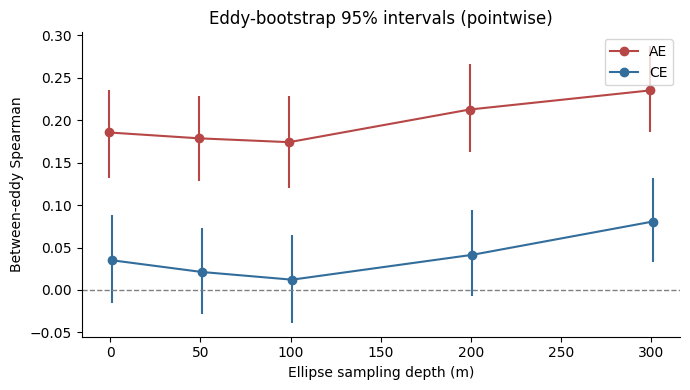

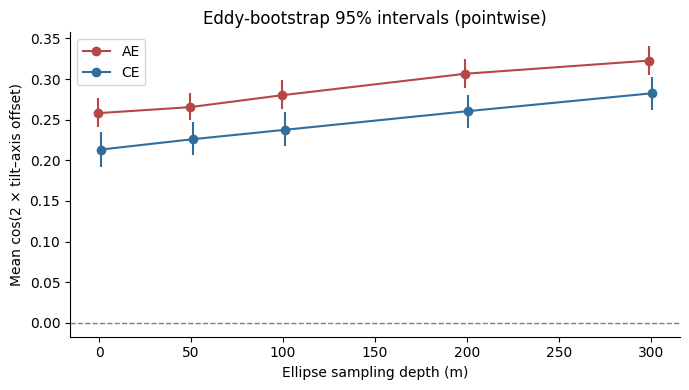

,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,AlignmentCos2,0.258020,0.240422,0.276176,1251,38152
1,0.0,AE,AlignmentSin2,-0.041608,-0.058934,-0.023285,1251,38152
2,0.0,AE,AlignmentDeg,35.487199,34.799962,36.147010,1251,38152
3,0.0,CE,AlignmentCos2,0.213216,0.192342,0.235223,1232,34185
4,0.0,CE,AlignmentSin2,0.047990,0.027563,0.066266,1232,34185
5,0.0,CE,AlignmentDeg,37.150859,36.334984,37.919873,1232,34185
6,50.0,AE,AlignmentCos2,0.265380,0.249124,0.282798,1251,38134
7,50.0,AE,AlignmentSin2,-0.039878,-0.055525,-0.022040,1251,38134
8,50.0,AE,AlignmentDeg,35.200257,34.569831,35.816785,1251,38134
9,50.0,CE,AlignmentCos2,0.225964,0.206871,0.247143,1232,34207


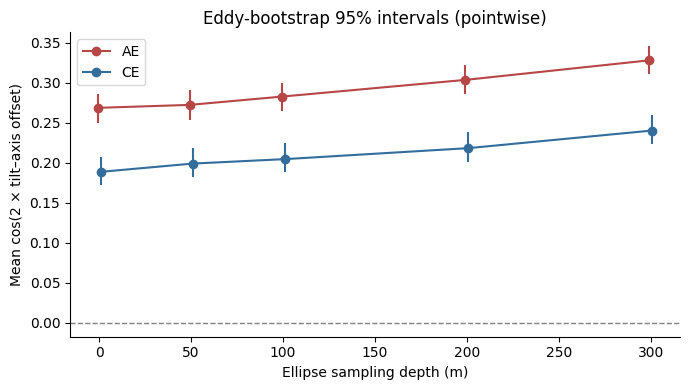

,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,AlignmentCos2,0.268563,0.249198,0.286308,1310,38715
1,0.0,AE,AlignmentSin2,-0.053797,-0.073053,-0.035521,1310,38715
2,0.0,AE,AlignmentDeg,35.105226,34.434943,35.813835,1310,38715
3,0.0,CE,AlignmentCos2,0.188633,0.171725,0.207614,1483,39745
4,0.0,CE,AlignmentSin2,0.036600,0.018451,0.054797,1483,39745
5,0.0,CE,AlignmentDeg,38.087260,37.372955,38.723843,1483,39745
6,50.0,AE,AlignmentCos2,0.272263,0.253555,0.290290,1310,38715
7,50.0,AE,AlignmentSin2,-0.049308,-0.067816,-0.031448,1310,38715
8,50.0,AE,AlignmentDeg,34.960207,34.281284,35.651693,1310,38715
9,50.0,CE,AlignmentCos2,0.198949,0.182223,0.218390,1483,39745


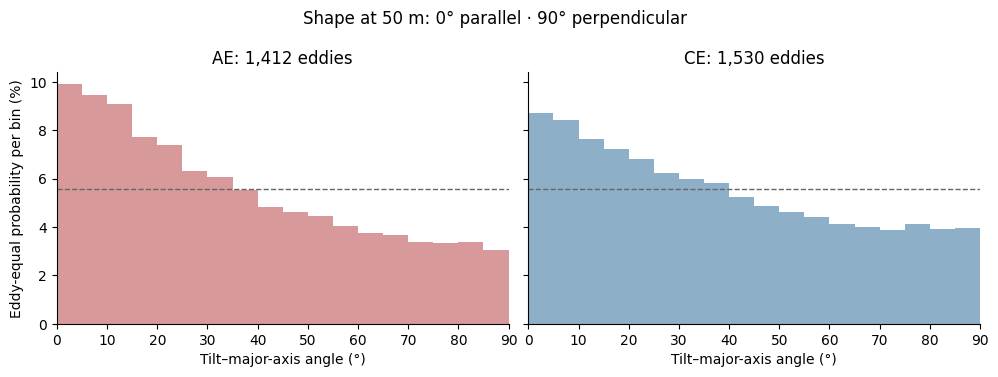

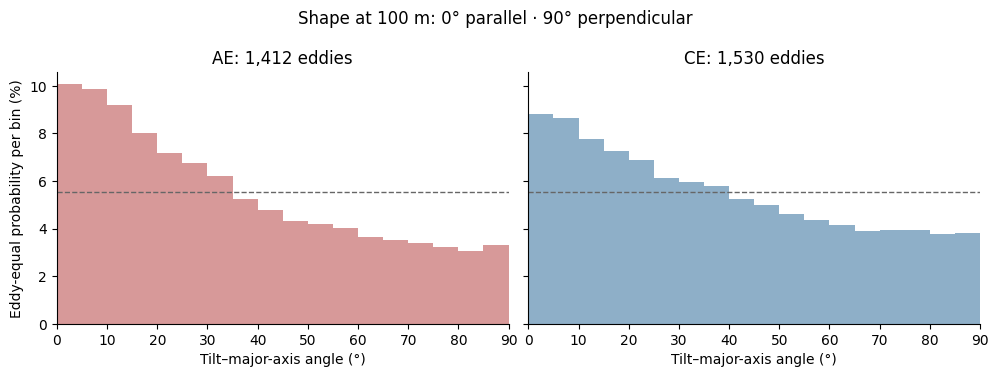

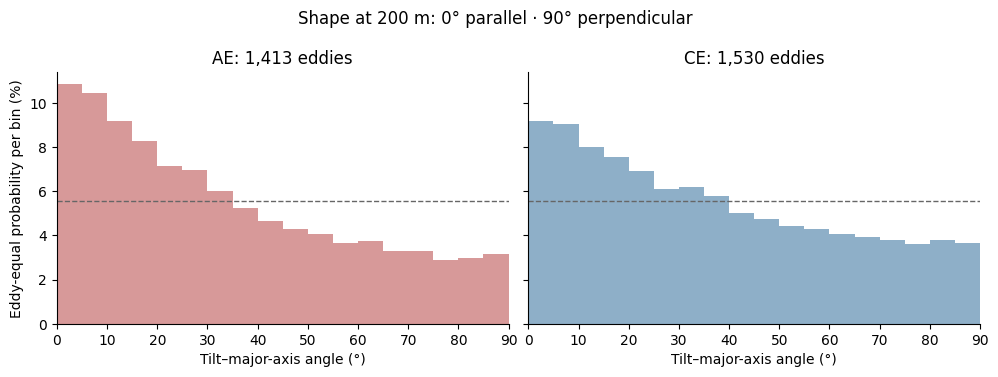

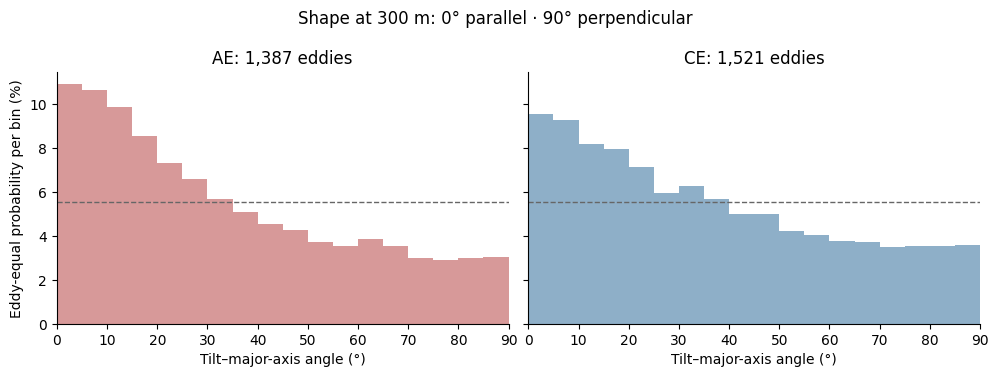

In [15]:
active_depths = DEPTHS if RUN_DEPTHS else (0,)
matched_magnitude = et.matched_depth_sample(magnitude, active_depths)
matched_direction = et.matched_depth_sample(direction, active_depths)
matched_mag_stats = et.magnitude_summary(matched_magnitude, **stat_kwargs)
matched_dir_stats = et.alignment_summary(matched_direction, **stat_kwargs)
print('Matched magnitude eddy-days:', len(matched_magnitude) // len(active_depths))
print('Matched direction eddy-days:', len(matched_direction) // len(active_depths))
for name, table in [('Available', mag_stats), ('Matched', matched_mag_stats)]:
    print(name)
    display(table)
    show_figure(name.lower() + '_depth_magnitude', et.plot_depth_summary(table, 'Between-eddy Spearman'))
for name, table in [('Available', dir_stats), ('Matched', matched_dir_stats)]:
    show_figure(name.lower() + '_depth_alignment', et.plot_depth_summary(table, 'AlignmentCos2'))
    display(table)
if RUN_DEPTHS:
    for depth in DEPTHS[1:]:
        show_figure(f'alignment_{depth}m', et.plot_alignment(direction, depth))

## 8. Sensitivity: near-circular eddies, small tilts and depth interpolation

Repeat surface alignment for AR thresholds 1.05/1.1/1.2/1.5 and tilt thresholds 0/5/10 km. Even the zero-threshold test excludes exactly zero tilt, whose direction is undefined. Record sample size alongside each result.

Nearest-depth sensitivity uses the same vertical range and a 25 m tolerance, never extrapolates, and compares **identical eddy-day-depth keys** with interpolated sampling. Inspect `DepthLower/DepthUpper` to see actual selected levels. If no common qualified observations exist, empty tables are expected.

In [16]:
sensitivity = []
for ar in (1.05, 1.1, 1.2, 1.5):
    for minimum_tilt in (0, 5, 10):
        g = et.select_rows(all_shapes.loc[all_shapes.ShapeDepth.eq(0)], directional=True,
                           min_ar=ar, min_tilt=minimum_tilt, max_ar=MAX_AR)
        g = g.loc[g.TiltDis.gt(0)]
        result = et.alignment_summary(g, **stat_kwargs)
        sensitivity.append(result.assign(min_ar=ar, min_tilt_km=minimum_tilt))
sensitivity = pd.concat(sensitivity, ignore_index=True)
display(sensitivity.loc[sensitivity.metric.eq('AlignmentCos2')])

nearest_comparison = {}
if RUN_DEPTHS:
    nearest_q = et.sample_depth_geometry(profiles, DEPTHS[1:], method='nearest',
                                         nearest_tolerance_m=NEAREST_TOLERANCE_M)
    nearest_all = et.build_analysis_table(surface, nearest_q, BEARING_OFFSET_DEG)
    for outcome in ('magnitude', 'direction'):
        directional = outcome == 'direction'
        a = et.select_rows(all_shapes, directional=directional, min_ar=MIN_DIRECTION_AR,
                           min_tilt=MIN_DIRECTION_TILT_KM, max_ar=MAX_AR)
        b = et.select_rows(nearest_all, directional=directional, min_ar=MIN_DIRECTION_AR,
                           min_tilt=MIN_DIRECTION_TILT_KM, max_ar=MAX_AR)
        keys = ['Eddy', 'Day', 'ShapeDepth']
        common = a[keys].merge(b[keys], on=keys, validate='one_to_one')
        summarise = et.alignment_summary if directional else et.magnitude_summary
        for label, frame in [('interpolated', a), ('nearest', b)]:
            use = frame.merge(common, on=keys, validate='one_to_one')
            result = summarise(use, **stat_kwargs)
            nearest_comparison[outcome + '_' + label] = result
            print(outcome, label)
            display(result)

,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations,min_ar,min_tilt_km
0,0.0,AE,AlignmentCos2,0.240615,0.223682,0.256579,1376,50168,1.05,0
3,0.0,CE,AlignmentCos2,0.159316,0.142946,0.176427,1519,49934,1.05,0
6,0.0,AE,AlignmentCos2,0.255490,0.238203,0.272137,1371,45916,1.05,5
9,0.0,CE,AlignmentCos2,0.178256,0.159680,0.196237,1512,44600,1.05,5
12,0.0,AE,AlignmentCos2,0.290969,0.273757,0.308579,1343,37571,1.05,10
15,0.0,CE,AlignmentCos2,0.230077,0.211346,0.249430,1429,34419,1.05,10
18,0.0,AE,AlignmentCos2,0.246241,0.229659,0.263488,1374,47707,1.10,0
21,0.0,CE,AlignmentCos2,0.162072,0.146410,0.179463,1518,48530,1.10,0
24,0.0,AE,AlignmentCos2,0.261271,0.243957,0.278237,1366,43812,1.10,5
27,0.0,CE,AlignmentCos2,0.181403,0.163312,0.198459,1511,43368,1.10,5


magnitude interpolated


,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,Between-eddy Spearman,0.172120,0.121444,0.223589,1377,51059
1,0.0,AE,Within-eddy slope (km / AR),4.636080,3.433038,5.841963,1377,51059
2,0.0,CE,Between-eddy Spearman,0.047034,-0.004477,0.099168,1519,50459
3,0.0,CE,Within-eddy slope (km / AR),2.828185,2.015761,3.663134,1519,50459
4,50.0,AE,Between-eddy Spearman,0.167961,0.117138,0.218042,1377,51032
5,50.0,AE,Within-eddy slope (km / AR),3.843134,2.818825,4.888078,1377,51032
6,50.0,CE,Between-eddy Spearman,0.029120,-0.020134,0.082242,1519,50411
7,50.0,CE,Within-eddy slope (km / AR),2.615557,1.892251,3.375265,1519,50411
8,100.0,AE,Between-eddy Spearman,0.166438,0.116049,0.219223,1377,51032
9,100.0,AE,Within-eddy slope (km / AR),4.260156,3.089413,5.353509,1377,51032


magnitude nearest


,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,Between-eddy Spearman,0.172120,0.121444,0.223589,1377,51059
1,0.0,AE,Within-eddy slope (km / AR),4.636080,3.433038,5.841963,1377,51059
2,0.0,CE,Between-eddy Spearman,0.047034,-0.004477,0.099168,1519,50459
3,0.0,CE,Within-eddy slope (km / AR),2.828185,2.015761,3.663134,1519,50459
4,50.0,AE,Between-eddy Spearman,0.167303,0.116463,0.217623,1377,51032
5,50.0,AE,Within-eddy slope (km / AR),3.811785,2.781880,4.820534,1377,51032
6,50.0,CE,Between-eddy Spearman,0.029933,-0.019837,0.083475,1519,50411
7,50.0,CE,Within-eddy slope (km / AR),2.589369,1.873098,3.338276,1519,50411
8,100.0,AE,Between-eddy Spearman,0.171363,0.119666,0.222901,1377,51032
9,100.0,AE,Within-eddy slope (km / AR),4.233242,3.116789,5.307413,1377,51032


direction interpolated


,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,AlignmentCos2,0.261271,0.243957,0.278237,1366,43812
1,0.0,AE,AlignmentSin2,-0.049525,-0.066470,-0.032356,1366,43812
2,0.0,AE,AlignmentDeg,35.362302,34.741639,36.012857,1366,43812
3,0.0,CE,AlignmentCos2,0.181403,0.163312,0.198459,1511,43368
4,0.0,CE,AlignmentSin2,0.039404,0.022102,0.056605,1511,43368
5,0.0,CE,AlignmentDeg,38.340860,37.697170,39.006368,1511,43368
6,50.0,AE,AlignmentCos2,0.268294,0.250112,0.284348,1369,43743
7,50.0,AE,AlignmentSin2,-0.047231,-0.063371,-0.031284,1369,43743
8,50.0,AE,AlignmentDeg,35.080401,34.475389,35.752338,1369,43743
9,50.0,CE,AlignmentCos2,0.193313,0.176300,0.211201,1511,43390


direction nearest


,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,AlignmentCos2,0.261271,0.243957,0.278237,1366,43812
1,0.0,AE,AlignmentSin2,-0.049525,-0.066470,-0.032356,1366,43812
2,0.0,AE,AlignmentDeg,35.362302,34.741639,36.012857,1366,43812
3,0.0,CE,AlignmentCos2,0.181403,0.163312,0.198459,1511,43368
4,0.0,CE,AlignmentSin2,0.039404,0.022102,0.056605,1511,43368
5,0.0,CE,AlignmentDeg,38.340860,37.697170,39.006368,1511,43368
6,50.0,AE,AlignmentCos2,0.267973,0.249774,0.284079,1369,43743
7,50.0,AE,AlignmentSin2,-0.047276,-0.063438,-0.031315,1369,43743
8,50.0,AE,AlignmentDeg,35.090741,34.488882,35.761258,1369,43743
9,50.0,CE,AlignmentCos2,0.193055,0.176113,0.210995,1511,43390


## 9. Interpretation and export

- Report AE and CE separately and distinguish the surface hypothesis from exploratory depth comparisons.
- Stronger typical elongation and positive within-eddy slopes together are more informative than a pooled eddy-day correlation alone. They still do not establish causation.
- Inspect full alignment distributions. Opposing or intermediate modes can cancel in mean trigonometric summaries.
- Context, threshold and sampling stability matter. Alignment with both topography and the ellipse may reflect shared environmental orientation.
- Shape and tilt come from related velocity fits. Common fitting errors, surface-Q smoothing and the tilt pipeline's temporal smoothing can induce associations or affect daily-rotation results.
- Tilt distance depends on the measured vertical span. A later adjusted analysis should account for fitted depth range, radius, age, latitude and environment before interpreting elongation as an independent driver.
- Bootstrap intervals assume independence between eddies; they do not account for correlations among neighbouring eddies or multiple exploratory comparisons.
- Compare with the earlier ML ellipse-feature ablation only as complementary evidence: predictive feature importance and these descriptive associations answer different questions.

No output files are written unless `SAVE_OUTPUTS=True`. The saved settings and coverage tables accompany the figures; the notebook is distributed with outputs cleared because the production data live on Katana.

In [17]:
if SAVE_OUTPUTS:
    OUTPUT.mkdir(parents=True, exist_ok=True)
    tables = dict(coverage=coverage, magnitude=mag_stats, direction=dir_stats,
                  matched_magnitude=matched_mag_stats, matched_direction=matched_dir_stats,
                  rotation=rotation_results, threshold_sensitivity=sensitivity,
                  **context_tables, **nearest_comparison)
    for name, table in tables.items():
        table.to_csv(OUTPUT / f'{name}.csv', index=False)
    for name, fig in figures.items():
        fig.savefig(OUTPUT / f'{name}.pdf', bbox_inches='tight')
        fig.savefig(OUTPUT / f'{name}.png', dpi=600, bbox_inches='tight')
    settings = dict(depths=active_depths, bearing_offset_deg=BEARING_OFFSET_DEG,
                    min_direction_ar=MIN_DIRECTION_AR, min_direction_tilt_km=MIN_DIRECTION_TILT_KM,
                    max_ar=MAX_AR, max_depth_bracket_m=MAX_DEPTH_BRACKET_M,
                    nearest_tolerance_m=NEAREST_TOLERANCE_M, n_boot=N_BOOT, seed=SEED,
                    min_days_per_eddy=MIN_DAYS_PER_EDDY, min_eddies=MIN_EDDIES,
                    paths={k: str(v) for k, v in vars(paths).items()})
    (OUTPUT / 'settings.json').write_text(json.dumps(settings, indent=2))
    print('Saved to', OUTPUT)
else:
    print('Review the figures and sensitivity tables before choosing final publication panels.')

Review the figures and sensitivity tables before choosing final publication panels.


## 10. Publication figures — ellipse geometry and measured tilt

This section is independent of the exploratory plotting cells: run the imports and data-loading cells through `all_shapes` first, then run from here. Earlier figures and results are preserved.

**Figure 1:** surface major-axis alignment, its association with deformation, and its depth dependence. AE and CE occupy separate rows. Primary directional filters remain tilt ≥5 km, axis ratio ≥1.1 and ≤5. These are measurement-quality criteria, not filters selected to maximise alignment. There is no filtering on the observed alignment angle.

**Figure 2:** surface deformation versus tilt magnitude. Small tilts and nearly circular shapes remain included; only invalid geometry/tilt values and AR >5 are excluded. Report the association as modest if the estimates remain small; the plots do not assume a positive result.

Every plotted sample requires ≥5 valid days per eddy; AR-class summaries apply that requirement **within each class**, avoiding equal weight for one-day class visits. Estimates with fewer than 20 eddies are suppressed and still listed in the coverage tables. These stricter support requirements may change numbers slightly relative to the exploratory plots.

The direction score is mean cos(2 × tilt–major-axis angle): +1 parallel, −1 perpendicular, 0 for a uniform angle distribution. It is not a correlation coefficient. Shading and whiskers are pointwise 95% whole-eddy bootstrap intervals, not simultaneous intervals. A zero/uniform reference is not an environment-matched independence test.

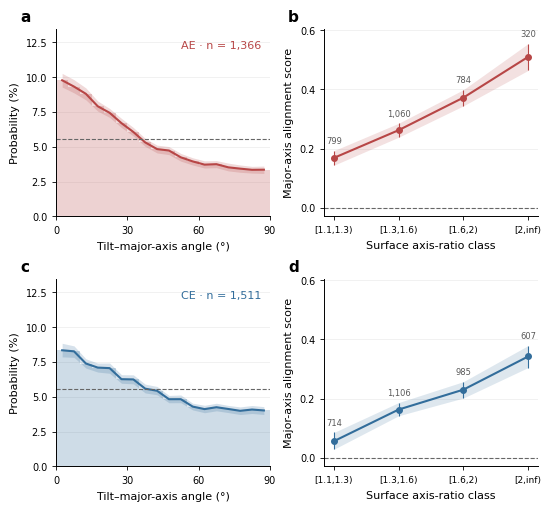

In [18]:
import importlib
import publication_tools as pub
pub = importlib.reload(pub)

PUB_DEPTHS = (0, 50, 100, 200, 300) if RUN_DEPTHS else (0,)
PUB_MIN_AR = 1.1
PUB_MIN_TILT_KM = 5.0
PUB_MAX_AR = 5.0
PUB_AR_EDGES = (1.1, 1.3, 1.6, 2, np.inf)
PUB_MIN_DAYS = 5
PUB_MIN_EDDIES = 20
PUB_N_BOOT = 1000
PUB_SEED = 42
PUB_SHOW_SENSITIVITY = True
PUB_SAVE = False  # PDF + 600 dpi PNG, tables and captions when this section runs
PUB_OUTPUT = HERE / 'outputs' / 'publication'

pub_filters = dict(depths=PUB_DEPTHS, min_ar=PUB_MIN_AR, min_tilt=PUB_MIN_TILT_KM,
                   max_ar=PUB_MAX_AR, min_days=PUB_MIN_DAYS, ar_edges=PUB_AR_EDGES)
pub_boot = dict(n_boot=PUB_N_BOOT, seed=PUB_SEED, min_eddies=PUB_MIN_EDDIES)
pub_figures, pub_tables, pub_captions = {}, {}, {}
pub_primary = pub.direction_data(all_shapes, **pub_filters, **pub_boot, equal_eddy=True)
# pub_figures['figure_1_alignment'] = pub.plot_direction(pub_primary)
# plt.show()

fig = pub.plot_direction(pub_primary)
axes = list(fig.axes)

# Remove the two depth panels.
fig.delaxes(axes[2])
fig.delaxes(axes[5])

# Rearrange the remaining panels into a 2 × 2 figure.
remaining = [axes[0], axes[1], axes[3], axes[4]]
layout = fig.add_gridspec(2, 2)

for i, ax in enumerate(remaining):
    ax.set_subplotspec(layout[i // 2, i % 2])

    # Relabel panels a, b, c, d.
    for text in ax.texts:
        if text.get_text() in ('a', 'b', 'd', 'e'):
            text.set_text('abcd'[i])

fig.set_size_inches(5.4, 5.0)

pub_figures['figure_1_alignment'] = fig
plt.show()

# for label in ('coverage', 'ar', 'depth', 'depth_contrasts'):
#     pub_tables['primary_' + label] = pub_primary[label]
#     print(label)
#     display(pub_primary[label])
# for cyc, table in pub_primary['histograms'].items():
#     pub_tables['primary_histogram_' + cyc] = table

In [19]:
pub_captions['figure_1_alignment'] = (
    'Figure 1. Eddy ellipse orientation and whole-column tilt. '
    'AE (upper row) and CE (lower row) are shown separately. '
    '(a,d) Surface tilt–major-axis angular distributions: 0° is parallel and 90° perpendicular. '
    'The dashed horizontal line is the uniform-angle reference, not a test of independence. '
    '(b,e) Mean major-axis alignment score across fixed surface axis-ratio classes. '
    'Connecting segments are visual guides, not fitted continuous relationships; point labels are eddy counts. '
    '(c,f) Alignment with ellipse geometry at each labelled depth, using identical eddy-days across all depths '
    'after directional QC. The same whole-column tilt is used at every depth. '
    f'Directional inclusion: tilt ≥{PUB_MIN_TILT_KM:g} km and {PUB_MIN_AR:g} ≤AR≤{PUB_MAX_AR:g}. '
    f'Each eddy requires ≥{PUB_MIN_DAYS} qualifying days within the plotted sample/class, '
    f'and estimates require ≥{PUB_MIN_EDDIES} eddies. '
    'Each eddy has equal total weight within its sample/class. '
    f'Shading and whiskers are pointwise 95% intervals from {PUB_N_BOOT:,} whole-eddy bootstrap resamples. '
    'The score is mean cos(2 × angular offset); it is not a correlation coefficient. '
    'Depth contrasts and sample sizes are provided in the accompanying tables.'
)
print(pub_captions['figure_1_alignment'])

Figure 1. Eddy ellipse orientation and whole-column tilt. AE (upper row) and CE (lower row) are shown separately. (a,d) Surface tilt–major-axis angular distributions: 0° is parallel and 90° perpendicular. The dashed horizontal line is the uniform-angle reference, not a test of independence. (b,e) Mean major-axis alignment score across fixed surface axis-ratio classes. Connecting segments are visual guides, not fitted continuous relationships; point labels are eddy counts. (c,f) Alignment with ellipse geometry at each labelled depth, using identical eddy-days across all depths after directional QC. The same whole-column tilt is used at every depth. Directional inclusion: tilt ≥5 km and 1.1 ≤AR≤5. Each eddy requires ≥5 qualifying days within the plotted sample/class, and estimates require ≥20 eddies. Each eddy has equal total weight within its sample/class. Shading and whiskers are pointwise 95% intervals from 1,000 whole-eddy bootstrap resamples. The score is mean cos(2 × angular offset

### Figure 2 — deformation and tilt magnitude

One point represents one eddy's median surface axis ratio and median tilt distance over the same valid days. The full observed range is shown; no high-tilt points are removed to improve the trend. Lines connect median tilt in six polarity-specific quantile bins of eddy-median AR; their bands are bootstrap confidence intervals on that median, not the spread of observations.

Panel (c) shows the equal-eddy within-eddy slope: deviations from each eddy's mean tilt regressed on deviations from its mean AR, with whole-eddy resampling. It is unadjusted for radius, measured vertical span, age and environment. Positive slopes indicate association, not that deformation causes tilt.

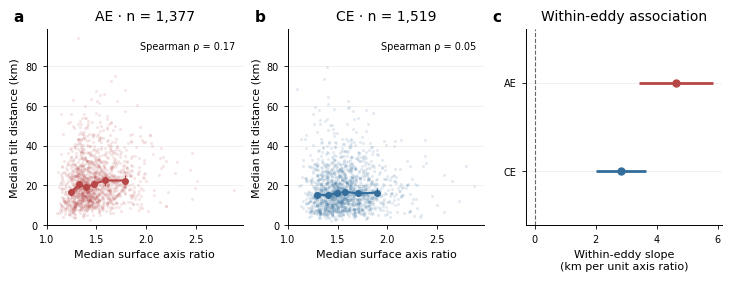

,ShapeDepth,Cyc,metric,estimate,low,high,eddies,observations
0,0.0,AE,Between-eddy Spearman,0.172120,0.121444,0.223589,1377,51059
1,0.0,AE,Within-eddy slope (km / AR),4.636080,3.433038,5.841963,1377,51059
2,0.0,CE,Between-eddy Spearman,0.047034,-0.004477,0.099168,1519,50459
3,0.0,CE,Within-eddy slope (km / AR),2.828185,2.015761,3.663134,1519,50459


,Cyc,x,estimate,low,high,eddies,lower,upper
0,AE,1.243423,16.656110,14.628763,18.085054,230,1.104,1.288
1,AE,1.326745,20.336641,18.700073,21.737534,229,1.288,1.361
2,AE,1.399214,18.829355,17.115787,20.500412,230,1.361,1.431
3,AE,1.474324,20.642363,18.900219,22.623369,229,1.431,1.521
4,AE,1.588360,22.389611,19.739658,24.686496,229,1.521,1.664
5,AE,1.790713,22.341100,20.346191,25.243019,230,1.664,2.891
6,CE,1.291497,15.221867,14.021114,16.648288,254,1.090,1.348
7,CE,1.401237,14.979736,14.127761,16.401588,253,1.348,1.449
8,CE,1.492347,15.982420,15.259423,17.331670,253,1.449,1.536
9,CE,1.579176,16.683016,15.256200,18.724089,253,1.536,1.635


Figure 2. Surface elongation and whole-column tilt magnitude. (a,b) Eddy-median axis ratio versus eddy-median tilt for AE and CE; all plotted eddies contribute one point. Lines join median tilt in six polarity-specific quantile bins of eddy-median axis ratio. Shading gives pointwise 95% bootstrap intervals on the bin medians, not interquartile spread. Spearman correlations quantify between-eddy associations. (c) Equal-eddy within-eddy slopes, with 95% whole-eddy bootstrap intervals. Zero tilt and nearly circular eddies are retained. Valid positive-definite geometry, 1≤AR≤5, and ≥5 valid days per eddy are required. Bin estimates require ≥20 eddies; 1,000 bootstrap resamples are used. These unadjusted associations do not demonstrate causation or independent predictive skill.


In [20]:
pub_mag = pub.magnitude_data(all_shapes, max_ar=PUB_MAX_AR, min_days=PUB_MIN_DAYS, **pub_boot)
pub_figures['figure_2_magnitude'] = pub.plot_magnitude(pub_mag)
plt.show()
for label in ('statistics', 'curves'):
    pub_tables['magnitude_' + label] = pub_mag[label]
    display(pub_mag[label])
pub_captions['figure_2_magnitude'] = (
    'Figure 2. Surface elongation and whole-column tilt magnitude. '
    '(a,b) Eddy-median axis ratio versus eddy-median tilt for AE and CE; '
    'all plotted eddies contribute one point. Lines join median tilt in six '
    'polarity-specific quantile bins of eddy-median axis ratio. Shading gives pointwise '
    '95% bootstrap intervals on the bin medians, not interquartile spread. '
    'Spearman correlations quantify between-eddy associations. '
    '(c) Equal-eddy within-eddy slopes, with 95% whole-eddy bootstrap intervals. '
    'Zero tilt and nearly circular eddies are retained. '
    f'Valid positive-definite geometry, 1≤AR≤{PUB_MAX_AR:g}, and ≥{PUB_MIN_DAYS} valid days per eddy are required. '
    f'Bin estimates require ≥{PUB_MIN_EDDIES} eddies; {PUB_N_BOOT:,} bootstrap resamples are used. '
    'These unadjusted associations do not demonstrate causation or independent predictive skill.'
)
print(pub_captions['figure_2_magnitude'])

### Weighting and threshold checks for Figure 1

The observation-weighted figure answers an eddy-day question rather than a typical-eddy question; **uncertainty still resamples whole eddies**. The stricter check uses AR ≥1.2 and tilt ≥10 km, specified here before comparing the panels. Retain the primary figure even if the stricter version looks stronger.

The depth-contrast table estimates **paired depth-minus-surface differences** in alignment score, preserving matched eddy-days and whole-eddy resampling. Its intervals are pointwise and exploratory. Consistent positive differences strengthen evidence for the depth pattern, but do not rule out differences in fit uncertainty or smoothing. The nearest-level check above did not cover 300 m in the first production run; do not describe that depth as validated against interpolation.

figure_s1_observation_weighted


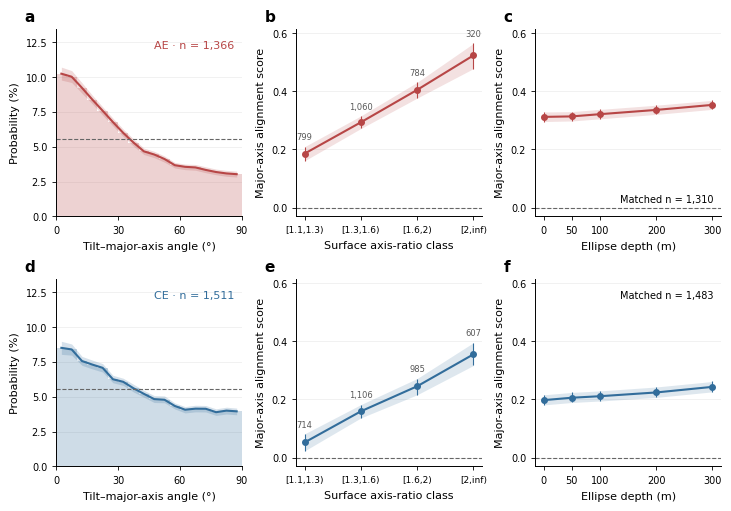

figure_s2_stricter_direction_qc


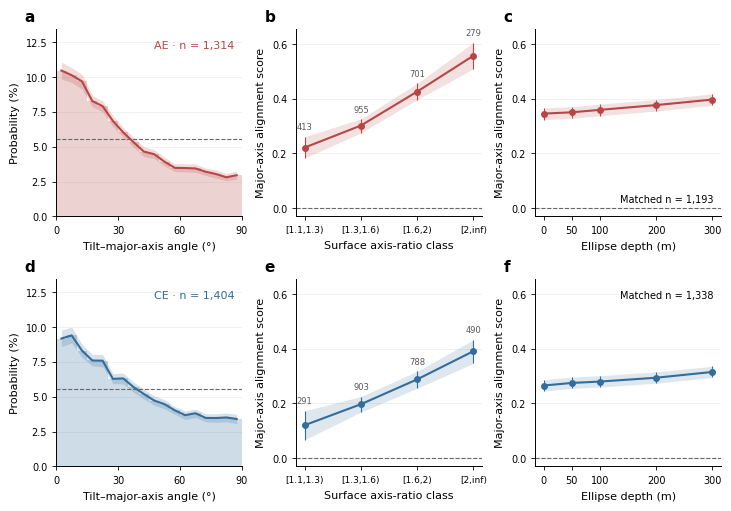

,Cyc,depth,estimate,low,high,eddies,observations,analysis
0,AE,0,0.268563,0.249198,0.286308,1310,38715,primary_equal_eddy
1,AE,50,0.272263,0.253555,0.290290,1310,38715,primary_equal_eddy
2,AE,100,0.282582,0.264125,0.300212,1310,38715,primary_equal_eddy
3,AE,200,0.303488,0.285724,0.321718,1310,38715,primary_equal_eddy
4,AE,300,0.327911,0.310925,0.345591,1310,38715,primary_equal_eddy
5,CE,0,0.188633,0.171725,0.207614,1483,39745,primary_equal_eddy
6,CE,50,0.198949,0.182223,0.218390,1483,39745,primary_equal_eddy
7,CE,100,0.204492,0.187846,0.224541,1483,39745,primary_equal_eddy
8,CE,200,0.218251,0.201537,0.237866,1483,39745,primary_equal_eddy
9,CE,300,0.240243,0.223836,0.259709,1483,39745,primary_equal_eddy


In [21]:
if PUB_SHOW_SENSITIVITY:
    cases = {
        'figure_s1_observation_weighted': dict(equal_eddy=False),
        'figure_s2_stricter_direction_qc': dict(equal_eddy=True, min_ar=1.2, min_tilt=10.0),
    }
    comparison_parts = []
    for name, changes in cases.items():
        options = dict(pub_filters, **pub_boot)
        options.update(changes)
        result = pub.direction_data(all_shapes, **options)
        pub_figures[name] = pub.plot_direction(result)
        print(name)
        plt.show()
        for label in ('coverage', 'ar', 'depth', 'depth_contrasts'):
            pub_tables[name + '_' + label] = result[label]
        for cyc, table in result['histograms'].items():
            pub_tables[name + '_histogram_' + cyc] = table
        comparison_parts.append(result['depth'].assign(analysis=name))
        weighting = 'Equal total weight per eddy' if options['equal_eddy'] else 'Equal weight per eddy-day observation'
        pub_captions[name] = (
            'Sensitivity version of Figure 1, with the same panel definitions. '
            f'{weighting}; tilt ≥{options["min_tilt"]:g} km and '
            f'{options["min_ar"]:g} ≤AR≤{options["max_ar"]:g}. '
            f'At least {PUB_MIN_DAYS} valid days per eddy per plotted sample/class and '
            f'{PUB_MIN_EDDIES} eddies per estimate are required. '
            f'Intervals resample whole eddies ({PUB_N_BOOT:,} replicates) under either weighting scheme. '
            'Depth panels use complete matched eddy-days; numbers above AR-class points are eddy counts. '
            'The stricter-QC sample changes membership and is not a paired test of threshold effects.'
        )
    comparison_parts.insert(0, pub_primary['depth'].assign(analysis='primary_equal_eddy'))
    pub_tables['sensitivity_depth_comparison'] = pd.concat(comparison_parts, ignore_index=True)
    display(pub_tables['sensitivity_depth_comparison'])

### Export publication figures and supporting numbers

Exports contain vector PDFs (scatter points rasterized), 600 dpi PNGs, plotted statistics/coverage CSVs, settings and draft captions. Captions describe estimands and uncertainty rather than asserting that the data must support the hypothesis. Review the generated panels and actual estimates before using them in the paper.

In [22]:
if PUB_SAVE:
    PUB_OUTPUT.mkdir(parents=True, exist_ok=True)
    for name, fig in pub_figures.items():
        fig.savefig(PUB_OUTPUT / f'{name}.pdf', bbox_inches='tight')
        fig.savefig(PUB_OUTPUT / f'{name}.png', dpi=600, bbox_inches='tight')
    for name, table in pub_tables.items():
        table.to_csv(PUB_OUTPUT / f'{name}.csv', index=False)
    (PUB_OUTPUT / 'captions.txt').write_text('\n\n'.join(pub_captions.values()))
    settings = dict(pub_filters, **pub_boot, primary_equal_eddy=True,
                    show_sensitivity=PUB_SHOW_SENSITIVITY,
                    strict_qc=dict(min_ar=1.2, min_tilt=10),
                    bearing_offset_deg=BEARING_OFFSET_DEG,
                    max_depth_bracket_m=MAX_DEPTH_BRACKET_M,
                    source_paths={k: str(v) for k,v in vars(paths).items()})
    (PUB_OUTPUT / 'settings.json').write_text(json.dumps(settings, indent=2))
    print('Publication figures, statistics and captions saved to:', PUB_OUTPUT)

## 11. Tilt–major-axis distributions by axis ratio

Three separate **1×2 figures**: all regions, shelf (S1/S2), and off-shelf (U1/U2/D1/D2). AE is on the left in shades of red; CE is on the right in shades of blue. Darker lines indicate larger axis ratios. Each line joins probabilities in **5° bins**, using Figure 1's style; no smoothing is applied.

The four classes are 1.1–1.3, 1.3–1.6, 1.6–2 and ≥2. The last class still respects the AR ≤5 quality limit. Tilt ≥5 km and AR ≥1.1 exclude poorly defined directions, with no filtering on the observed alignment angle. At least five qualifying days are required per eddy **within the selected region group and AR class**, and a line requires at least 20 eddies. Each eddy receives equal total weight within each line. An eddy may contribute to more than one class or region group.

Each displayed line sums to 100% across its 18 angle bins. Zero degrees is parallel to the major axis; 90° is perpendicular. The dashed line is a uniform-angle reference, not a formal independence test. Faint bands are pointwise whole-eddy bootstrap 95% intervals; set `ARH_SHOW_CI=False` for lines alone. Axis scales and class colours are shared across the three figures.

This section needs the earlier imports and data loading through `all_shapes`. It does not require running the other publication figures.

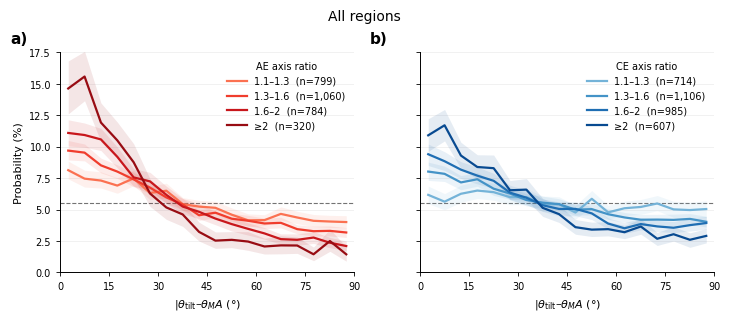

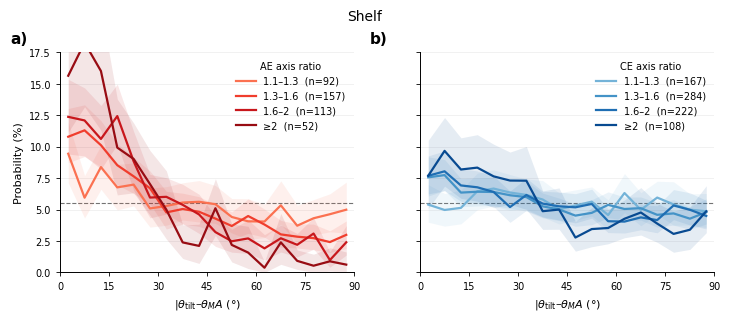

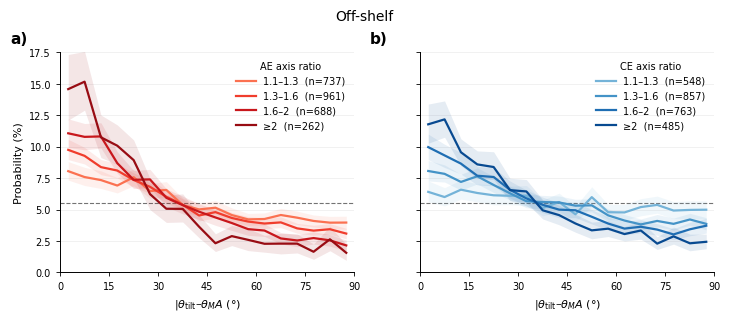

In [23]:
import importlib
import publication_tools as pub
pub = importlib.reload(pub)

ARH_EDGES = (1.1, 1.3, 1.6, 2, np.inf)
ARH_MIN_AR = 1.1
ARH_MIN_TILT_KM = 5.0
ARH_MAX_AR = 5.0
ARH_MIN_DAYS = 5
ARH_MIN_EDDIES = 20
ARH_N_BOOT = 1000
ARH_SEED = 42
ARH_SHOW_CI = True
ARH_SAVE = False  # True exports PDF, 600 dpi PNG, CSVs and captions
ARH_OUTPUT = HERE / 'outputs' / 'publication'

arh_options = dict(ar_edges=ARH_EDGES, min_ar=ARH_MIN_AR, min_tilt=ARH_MIN_TILT_KM,
                   max_ar=ARH_MAX_AR, min_days=ARH_MIN_DAYS, min_eddies=ARH_MIN_EDDIES,
                   n_boot=ARH_N_BOOT, seed=ARH_SEED, equal_eddy=True)
arh_regions = {
    'all': ('All regions', None),
    'shelf': ('Shelf', ['S1', 'S2']),
    'off_shelf': ('Off-shelf', ['U1', 'U2', 'D1', 'D2']),
}
arh_results = {name: pub.ar_histogram_data(all_shapes, regions=regions, **arh_options)
               for name, (title, regions) in arh_regions.items()}
# Identical y-limits make regional changes directly comparable.
arh_peaks = [r['histograms']['high' if ARH_SHOW_CI else 'estimate'].max()
             for r in arh_results.values()]
arh_ymax = 17.5 #max([10.] + [float(p)*1.18 for p in arh_peaks if np.isfinite(p)])
arh_figures, arh_captions = {}, {}
for name, (title, regions) in arh_regions.items():
    result = arh_results[name]
    arh_figures[name] = pub.plot_ar_histograms(result, title=title,
                                               show_ci=ARH_SHOW_CI, ymax=arh_ymax)
    plt.show()
    # display(result['coverage'])
    # arh_captions[name] = (
    #     f'Surface tilt–major-axis angular distributions by axis ratio: {title.lower()}. '
    #     'AE (left) uses red shades; CE (right) uses blue shades. Darker lines indicate greater elongation. '
    #     'Lines join probabilities in 5° bins without smoothing; 0° is parallel and 90° perpendicular. '
    #     f'Tilt ≥{ARH_MIN_TILT_KM:g} km and {ARH_MIN_AR:g}≤AR≤{ARH_MAX_AR:g} are required; '
    #     'finite classes include the lower edge and exclude the upper edge, while the last class includes the QC maximum. '
    #     f'Each eddy requires ≥{ARH_MIN_DAYS} valid days within its region group and AR class; '
    #     f'lines require ≥{ARH_MIN_EDDIES} eddies. Legend n denotes eligible eddies for that line. '
    #     'Each eddy has equal total weight per line; individual eddies can contribute to multiple classes. '
    #     'Each line sums to 100%; the dashed line is a uniform-angle reference, not a test of independence. '
    #     + (f'Shading shows pointwise 95% intervals from {ARH_N_BOOT:,} whole-eddy bootstrap resamples. '
    #        if ARH_SHOW_CI else 'Confidence intervals are supplied in the accompanying CSV tables. ')
    #     + 'The three region figures share axis limits and class colours.'
    # )

In [24]:
if ARH_SAVE:
    ARH_OUTPUT.mkdir(parents=True, exist_ok=True)
    for name, fig in arh_figures.items():
        stem = 'alignment_by_axis_ratio_' + name
        fig.savefig(ARH_OUTPUT / f'{stem}.pdf', bbox_inches='tight')
        fig.savefig(ARH_OUTPUT / f'{stem}.png', dpi=600, bbox_inches='tight')
        for table in ('histograms', 'coverage'):
            arh_results[name][table].to_csv(ARH_OUTPUT / f'{stem}_{table}.csv', index=False)
        (ARH_OUTPUT / f'{stem}_caption.txt').write_text(arh_captions[name])
    # JSON uses a string for the open-ended upper class, rather than non-standard Infinity.
    settings = dict(arh_options, ar_edges=[float(x) if np.isfinite(x) else 'inf' for x in ARH_EDGES],
                    regions=arh_regions, show_ci=ARH_SHOW_CI, shared_ymax=arh_ymax,
                    bearing_offset_deg=BEARING_OFFSET_DEG,
                    source_paths={k: str(v) for k, v in vars(paths).items()})
    (ARH_OUTPUT / 'alignment_by_axis_ratio_settings.json').write_text(json.dumps(settings, indent=2))
    print('Saved axis-ratio distribution figures to:', ARH_OUTPUT)